## 10.3.4 随机森林分类器实践

## 10.3.4.1 随机森林分类树的三行代码

In [1]:
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataFile = '/Users/lirenyuan/Desktop/maitian/course/data/breast_cancer_m.csv'
data = pd.read_csv(dataFile)
X = data.iloc[: ,0:-1]
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 21)

In [3]:
clf_rf = RandomForestClassifier()
clf_rf.fit(X_train, y_train)
score = clf_rf.score(X_test, y_test)
score

0.9649122807017544

## 10.3.4.2 学习曲线

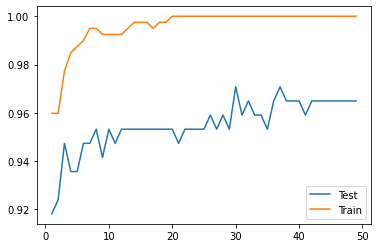

0.9707602339181286 30


In [4]:
scoreTrainList, scoreTestList = [], []
for i in range(1,50):
    clf_rf = RandomForestClassifier( random_state = 11
                                    , n_estimators = i
                                   )
    clf_rf.fit(X_train, y_train)
    score_test = clf_rf.score(X_test, y_test)
    score_train = clf_rf.score(X_train,y_train)
    scoreTestList.append(score_test)
    scoreTrainList.append(score_train)
plt.plot(range(1,50), scoreTestList, label = 'Test')
plt.plot(range(1,50), scoreTrainList, label = 'Train')
plt.legend()
plt.show()
print(max(scoreTestList),scoreTestList.index(max(scoreTestList))+1)
# 这里注意list序号（index）和评估器数目i的区别

## 10.3.4.3 使用袋外数据作为验证集

/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_forest.py:541: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "
/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_forest.py:545: RuntimeWarning: invalid value encountered in true_divide
  decision = (predictions[k] /
/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_forest.py:541: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "
/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_forest.py:545: RuntimeWarning: invalid value encountered in true_divide
  decision = (predictions[k] /
/opt/anaconda3/lib/python3.8/site-packages/sklearn/ensemble/_forest.py:541: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were 

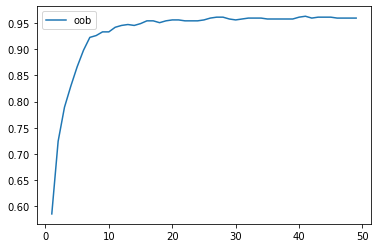

0.9630931458699473 41


In [5]:
scoreList = []
for i in range(1,50):
    clf_rf = RandomForestClassifier( random_state = 11
                                    , n_estimators = i
                                    , oob_score = True
                                   )
    clf_rf.fit(X, y)
    score = clf_rf.oob_score_
    scoreList.append(score)
plt.plot(range(1,50), scoreList, label = 'oob')
plt.legend()
plt.show()
print(max(scoreList),scoreList.index(max(scoreList))+1)

## 10.3.5 数据划分

......  
交叉验证法

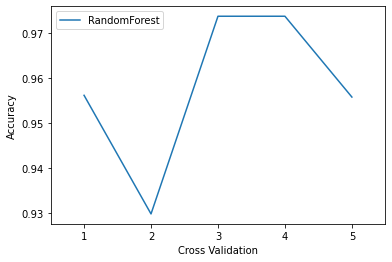

0.9578171091445429 0.016088429745936057


In [6]:
from sklearn.model_selection import cross_val_score
clf_rf = RandomForestClassifier(n_estimators=11)
clf_rf_cv = cross_val_score(clf_rf,X,y,cv=5
#                            ,scoring = 'neg_mean_squared_error'
                           )
plt.plot(range(1,6),clf_rf_cv,label = "RandomForest")
plt.xlabel("Cross Validation")
plt.ylabel("Accuracy")
plt.xlim(0.5,5.5)
plt.legend()
plt.show()
print(clf_rf_cv.mean(),clf_rf_cv.std())

## 10.3.6 校准曲线

In [7]:
from sklearn.calibration import calibration_curve
clf_rf = RandomForestClassifier()
clf_rf.fit(X_train, y_train)
fraction_of_positives, mean_predicted_value = \
calibration_curve(y_test, clf_rf.predict_proba(X_test)[:,1], n_bins = 5
#                   , strategy = 'quantile'
                 )
fraction_of_positives, mean_predicted_value

(array([0.        , 0.        , 0.5       , 0.88888889, 0.97916667]),
 array([0.03943396, 0.29666667, 0.489     , 0.71222222, 0.980625  ]))

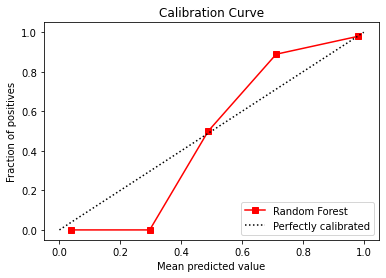

In [8]:
plt.plot(mean_predicted_value, fraction_of_positives, "rs-", label = 'Random Forest')
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend(loc="lower right")
plt.show()